# Posture Detection - Full Pipeline

## Overview
This notebook covers the full machine learning pipeline for real-time posture classification using IMU data collected from two ESP32 nodes.

## Hardware
- 3× ESP32 WROOM-32 (1 as a master)
- 2× MPU6050 (accelerometer + gyroscope)
- Node **lombar**: lower back
- Node **esterno**: chest

## Data Collection
- Sampling rate: 50Hz (50 samples per second)
- Session duration: ~20 seconds per session
- 5 sessions per class

## Classes
| Label | Description |
|-------|-------------|
| `seated_good` | Correct seated posture |
| `seated_bad_front` | Leaning forward (seated) |
| `seated_bad_back` | Leaning back (seated) |
| `standing_good` | Correct standing posture |
| `standing_bad_front` | Leaning forward (standing) |

## Pipeline
1. Imports & Setup
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Model Training
6. Export to TFLite

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# encontrar a pasta certa automaticamente
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if any(d in dirs for d in ["seated_good", "standing_good", "seated_bad_front"]):
        os.chdir(root)
        print(f"Encontrado: {root}")
        break

## 1. Imports and Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", None)

print(f"TensorFlow version: {tf.__version__}")
print("Libraries loaded.")

TensorFlow version: 2.21.0
Libraries loaded.


## Load Data

In [ ]:
#import os
#os.chdir("/content/project/an-embedding-ai-system-for-posture-detection-master")
#print(os.getcwd())

In [ ]:
import os
os.chdir("/content/drive/MyDrive/an-embedding-ai-system-for-posture-detection-master")
print("Diretório atual:", os.getcwd())

In [ ]:
dfs = []
base = "."

VALID_LABELS = ["seated_bad_back", "seated_bad_front", "seated_good", "standing_bad_front", "standing_good"]


for root, dirs, files in os.walk(base):
    dirs[:] = [d for d in dirs if d not in [".venv", ".git", "__pycache__"]]

    for file in files:
        if file.endswith(".csv"):
            path = os.path.join(root, file)
            label = os.path.normpath(root).replace(os.path.normpath(base), "").strip(os.sep)
            label = label.replace(os.sep, "_")

            if label not in VALID_LABELS:
                continue

            df = pd.read_csv(path)
            df["label"] = label
            df["session"] = f"{label}/{file}"   # <-- NOVO
            dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"Total rows:    {data.shape[0]}")
print(f"Total columns: {data.shape[1]}")
print(f"\nLabels found:\n{data['label'].value_counts()}")
data.head()

Total rows:    49565
Total columns: 11

Labels found:
label
standing_bad_front    10743
seated_good           10236
seated_bad_front       9682
seated_bad_back        9644
standing_good          9260
Name: count, dtype: int64


,timestamp,node,ax,ay,az,gx,gy,gz,t_ms,label,session
0,2026-05-19 20:10:00,lombar,9524,-1744,-12920,-277,-243,417,979809,seated_bad_back,seated_bad_back/bbs1.csv
1,2026-05-19 20:10:00,esterno,3236,10400,11448,-236,-331,231,322376,seated_bad_back,seated_bad_back/bbs1.csv
2,2026-05-19 20:10:00,lombar,9488,-1680,-12908,-324,-189,439,979831,seated_bad_back,seated_bad_back/bbs1.csv
3,2026-05-19 20:10:00,esterno,2944,10064,11336,-15,-224,90,322398,seated_bad_back,seated_bad_back/bbs1.csv
4,2026-05-19 20:10:00,lombar,9536,-1816,-13124,-335,-296,382,979853,seated_bad_back,seated_bad_back/bbs1.csv


### Dataset Structure

The dataset contains **49,565 rows** and **10 columns**. Each row represents a single
IMU reading from one of the two sensor nodes at a given point in time.

| Column | Type | Description |
|--------|------|-------------|
| `timestamp` | string | Wall-clock time of the reading, recorded by the Python server on the PC |
| `node` | string | Sensor node identifier - `lombar` (lower back) or `esterno` (chest) |
| `ax` | int16 | Raw accelerometer reading on the X axis (LSB units) |
| `ay` | int16 | Raw accelerometer reading on the Y axis (LSB units) |
| `az` | int16 | Raw accelerometer reading on the Z axis (LSB units) |
| `gx` | int16 | Raw gyroscope reading on the X axis (LSB units) |
| `gy` | int16 | Raw gyroscope reading on the Y axis (LSB units) |
| `gz` | int16 | Raw gyroscope reading on the Z axis (LSB units) |
| `t_ms` | int64 | Milliseconds since ESP32 boot - used for node synchronization |
| `label` | string | Posture class assigned from the folder structure at collection time |

Accelerometer values represent the projection of gravitational and inertial forces onto
each axis. Gyroscope values represent angular velocity around each axis. Both are stored
as raw 16-bit integer values from the MPU6050 — no scaling or calibration has been applied yet.

`t_ms` is independent per node since each ESP32 boots separately. It is used in the
preprocessing step to synchronize lombar and esterno readings by nearest-neighbor matching.

In [3]:
# Merge 5 classes → 3 classes
MERGE = {
    "seated_bad_back":   "bad_back",
    "seated_bad_front":  "bad_front",
    "standing_bad_front":"bad_front",
    "seated_good":       "good",
    "standing_good":     "good",
}
data["label"] = data["label"].map(MERGE)
print(data["label"].value_counts())

label
bad_front    20425
good         19496
bad_back      9644
Name: count, dtype: int64


The five original classes have been merged into three by collapsing the seated/standing
distinction. The merge is justified by the EDA finding that the four non-reclining classes
cluster together in feature space - the sensors measure trunk orientation, which is
identical regardless of whether the person is seated or standing.

| New label | Original labels merged |
|-----------|------------------------|
| `bad_back` | `seated_bad_back` |
| `bad_front` | `seated_bad_front`, `standing_bad_front` |
| `good` | `seated_good`, `standing_good` |

The resulting distribution remains acceptable: `bad_front` (20,425), `good` (19,496),
`bad_back` (9,644). `bad_back` has roughly half the samples of the other two, which is
expected given it was a single original class. No corrective measures are applied at this
stage.

## 3. Exploratory Data Analysis

### 3.1 Class Distribution

Before any preprocessing, we examine how samples are distributed across the five posture classes.
An imbalanced dataset can bias the model toward majority classes, leading to poor performance
on underrepresented ones. Understanding the distribution early allows us to decide whether
corrective measures, such as class weighting or oversampling, are needed.

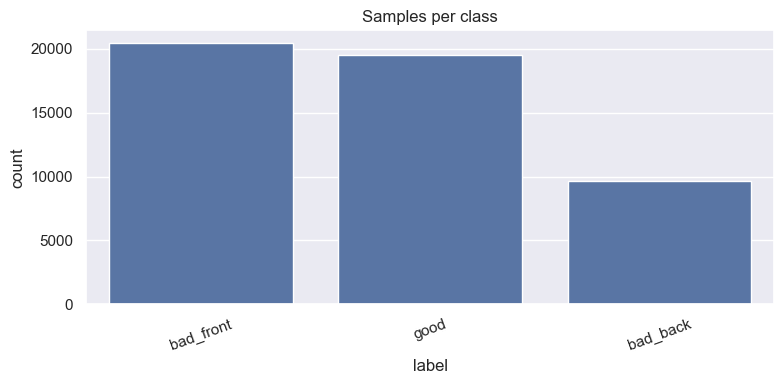

In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x="label", order=data["label"].value_counts().index)
plt.xticks(rotation=20)
plt.title("Samples per class")
plt.tight_layout()
plt.show()

The dataset contains **49,565 samples** across 5 classes. The distribution is mildly imbalanced:
`standing_bad_front` is the largest class (~10,743 samples) while `standing_good` is the smallest
(~9,260 samples), a difference of roughly 16%. This level of imbalance is not severe enough to
require oversampling. Instead, class weights will be applied during training to compensate.

### 3.2 Data Quality

A clean dataset is a prerequisite for a reliable model. Here we check for null values,
duplicate rows, data types, and node balance. Any issues found at this stage must be
resolved before preprocessing.

In [5]:
print("Null values:\n", data.isnull().sum())
print(f"\nDuplicate rows: {data.duplicated().sum()}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nNode distribution:\n{data['node'].value_counts()}")

Null values:
 timestamp    0
node         0
ax           0
ay           0
az           0
gx           0
gy           0
gz           0
t_ms         0
label        0
session      0
dtype: int64

Duplicate rows: 0

Data types:
timestamp    object
node         object
ax            int64
ay            int64
az            int64
gx            int64
gy            int64
gz            int64
t_ms          int64
label        object
session      object
dtype: object

Node distribution:
node
esterno    24784
lombar     24781
Name: count, dtype: int64


The dataset is clean: no null values, no duplicate rows. Both nodes are nearly perfectly
balanced (esterno: 24,784 / lombar: 24,781), confirming both ESP32s sampled consistently
throughout the collection sessions. The `timestamp` column is stored as a string object
and will be converted to datetime in the preprocessing step.

### 3.3 Signal Visualization per Class

To verify that the sensors are producing meaningful data, we plot a 100-sample window
of raw IMU readings for each node on the `seated_good` class. This allows us to visually
inspect signal stability, noise levels, and sensor orientation

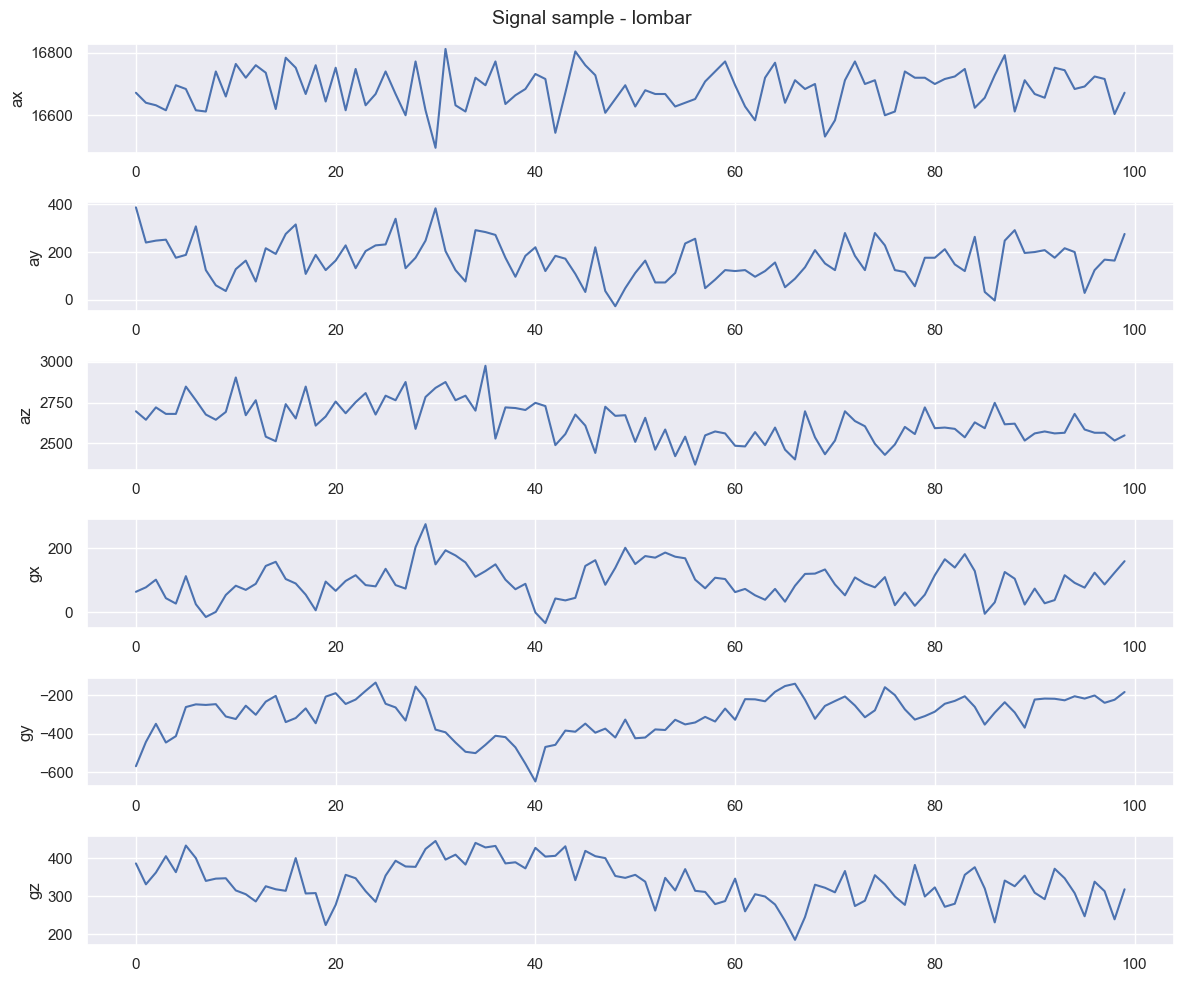

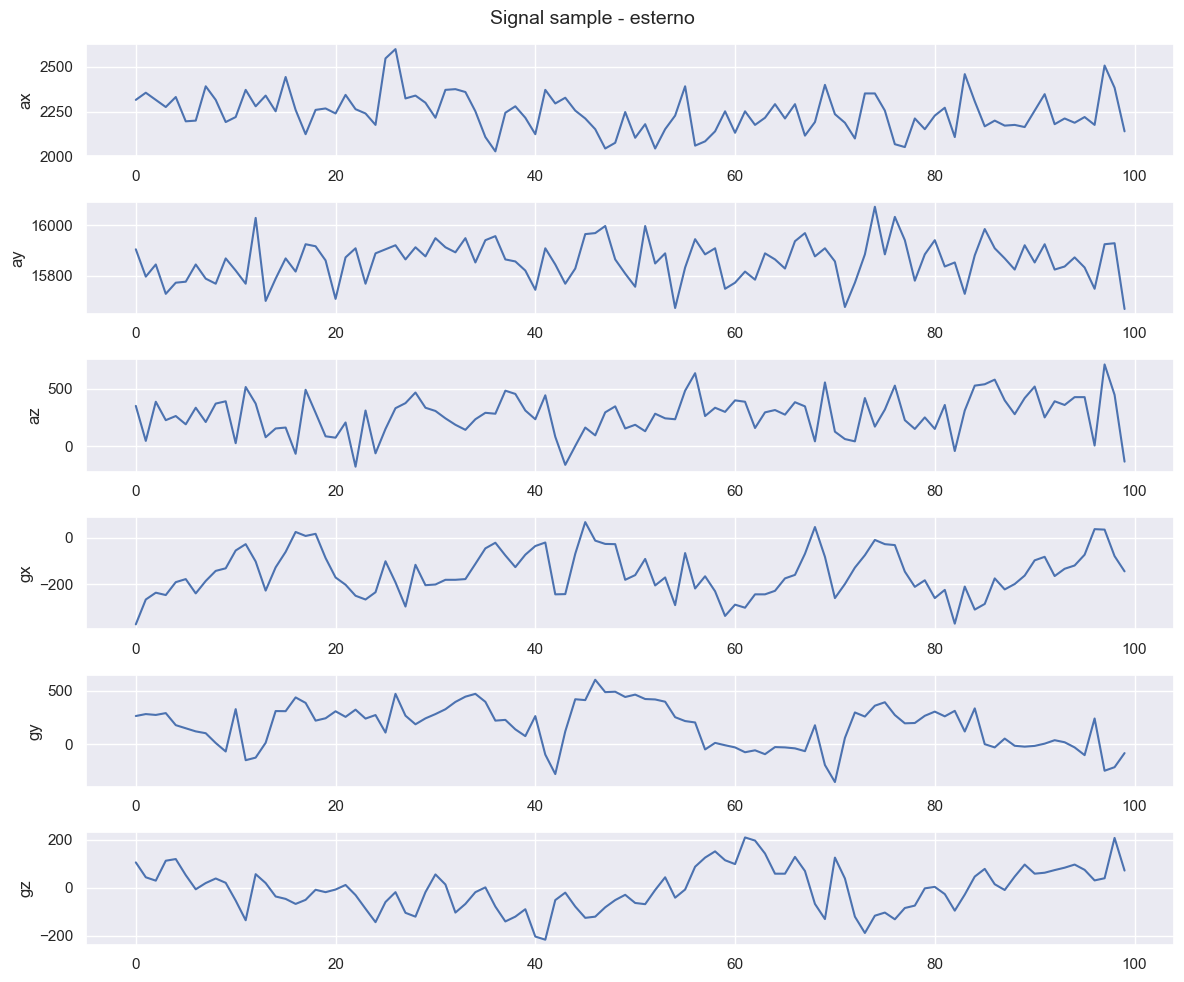

In [8]:
features = ["ax", "ay", "az", "gx", "gy", "gz"]
nodes = ["lombar", "esterno"]

for node in nodes:
    fig, axes = plt.subplots(len(features), 1, figsize=(12, 10), sharex=False)
    fig.suptitle(f"Signal sample - {node}", fontsize=14)

    sample = data[(data["node"] == node) & (data["label"] == "good")].head(100)

    for i, feat in enumerate(features):
        axes[i].plot(sample[feat].values)
        axes[i].set_ylabel(feat)

    plt.tight_layout()
    plt.show()

The plots show 100 consecutive raw IMU samples (~2 seconds at 50Hz) from a `good` posture
session, for each node independently.

**Lombar:** `ax` dominates with a stable high value (~16,700), consistent with gravity
acting along that axis when the torso is upright. The remaining features oscillate around
low values, reflecting natural body micro-movements.

**Esterno:** `ay` dominates (~15,800), again driven by gravity orientation on the chest
sensor. `az` and the gyroscope channels show more variability than the lombar node,
expected given the chest moves more freely than the lower back.

Both signals confirm the sensors are capturing stable postural orientation with low-frequency
noise, suitable for windowed classification.

### 3.4 Node Synchronization

Since both ESP32 nodes operate independently with separate clocks, their samples are not
perfectly aligned in time. Before merging lombar and esterno into a single feature vector,
we verify that both nodes are capturing data at approximately the same rate within each class.

A large difference in sample count between nodes for the same class would indicate dropped
packets or connectivity issues during data collection, which would complicate the merge step.

In [9]:
lombar  = data[data["node"] == "lombar"].copy()
esterno = data[data["node"] == "esterno"].copy()

print(f"{'Label':25s} | {'Lombar':>8} | {'Esterno':>8} | {'Diff':>6}")
print("-" * 55)
for label in sorted(data["label"].unique()):
    l = len(lombar[lombar["label"] == label])
    e = len(esterno[esterno["label"] == label])
    print(f"{label:25s} | {l:>8} | {e:>8} | {abs(l-e):>6}")

Label                     |   Lombar |  Esterno |   Diff
-------------------------------------------------------
bad_back                  |     4822 |     4822 |      0
bad_front                 |    10213 |    10212 |      1
good                      |     9746 |     9750 |      4


The results confirm excellent synchronization between both nodes across all classes.
The maximum difference between lombar and esterno sample counts is **4 samples**,
negligible at 50Hz, corresponding to less than 80 milliseconds of drift.

This means the nearest-neighbor merge in the preprocessing step will produce
near-perfect pairs with minimal temporal mismatch, and no samples need to be discarded.

The dataset is ready for preprocessing.

### 3.5 Feature Distributions per Class

Boxplots allow us to assess whether each IMU feature carries discriminative information
across posture classes. If the distributions of a feature overlap significantly across
all classes, that feature contributes little to classification. Features with clear
separation between classes are the most valuable for the model.

We analyze both nodes separately, as the same feature may behave differently depending
on sensor placement.

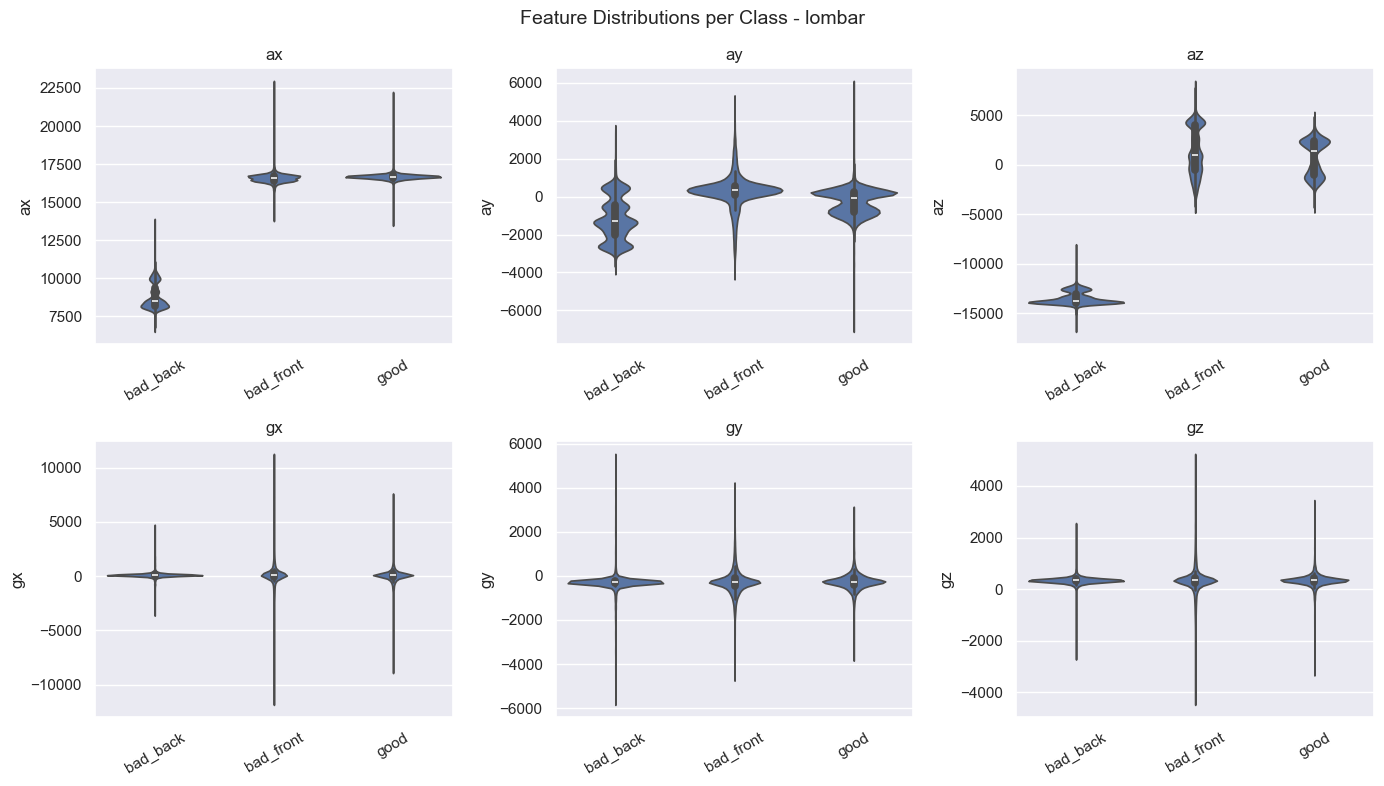

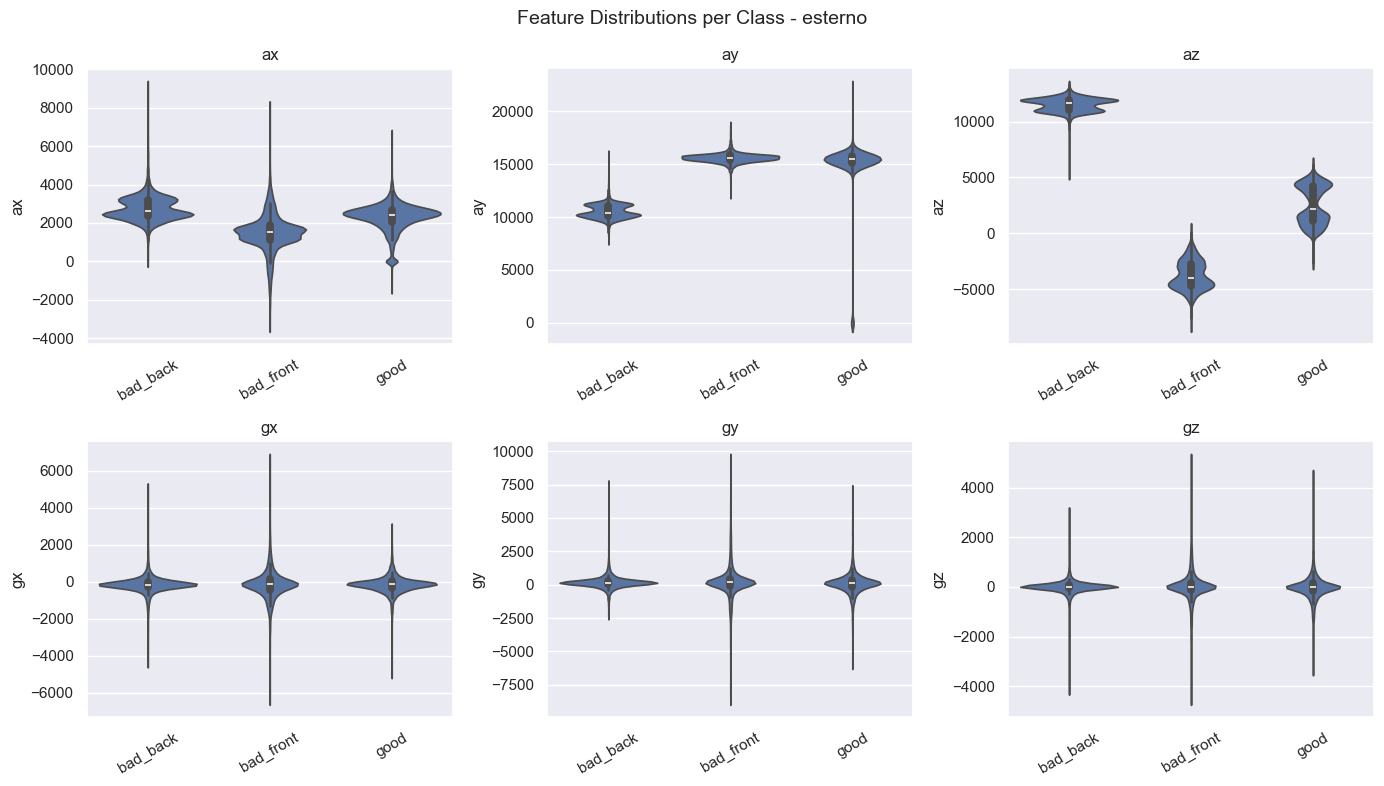

In [11]:
features = ["ax", "ay", "az", "gx", "gy", "gz"]

for node, node_data in [("lombar", lombar), ("esterno", esterno)]:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"Feature Distributions per Class - {node}", fontsize=14)
    axes = axes.flatten()

    for i, feat in enumerate(features):
        sns.violinplot(data=node_data, x="label", y=feat, ax=axes[i], inner="box", order=["bad_back", "bad_front", "good"])
        axes[i].set_title(feat)
        axes[i].set_xlabel("")
        axes[i].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

**Lombar node:**
`ax` and `az` are the strongest discriminators: `bad_back` is completely isolated, with
`ax` median ~8,500 (vs ~16,500 for the other two) and `az` median ~-13,000 (vs near-zero).
`bad_front` and `good` overlap heavily on all lombar features, with no clean separation
visible in any single feature. Notably, `ay` for `bad_back` shows a bimodal distribution,
suggesting two distinct sub-patterns within that class likely corresponding to the original
seated and standing sessions before merging. Gyroscope features are centered near zero across
all classes with wide spread meaning low individual discriminative power.

**Esterno node:**
`ay` clearly separates `bad_back` (~10,000) from `bad_front` and `good` (~15,500–16,000).
`az` is the most useful feature for separating the three classes: `bad_back` is strongly
positive (~10,000), `good` is moderately positive (~3,000), and `bad_front` is negative
(~-4,500), a clean ordering across all three classes. Gyroscope features again show
near-zero medians with heavy spread and no meaningful separation.

**Overall:** `bad_back` is trivially separable on both nodes via accelerometer data alone.
The key challenge is `bad_front` vs `good`, where the esterno `az` provides the strongest
signal. Temporal context from windowing will be essential to distinguish these two classes reliably.

### 3.6 Pairwise Feature Scatter

Scatter plots between pairs of features reveal whether classes form distinct clusters in
2D feature space. If two features together separate the classes well, they are strong
candidates for classification. This analysis complements the boxplots by showing
inter-feature relationships rather than individual distributions.

We focus on the most discriminative accelerometer features identified in 3.5:
`ax` and `az` for the lombar node, and `ay` and `az` for the esterno node.

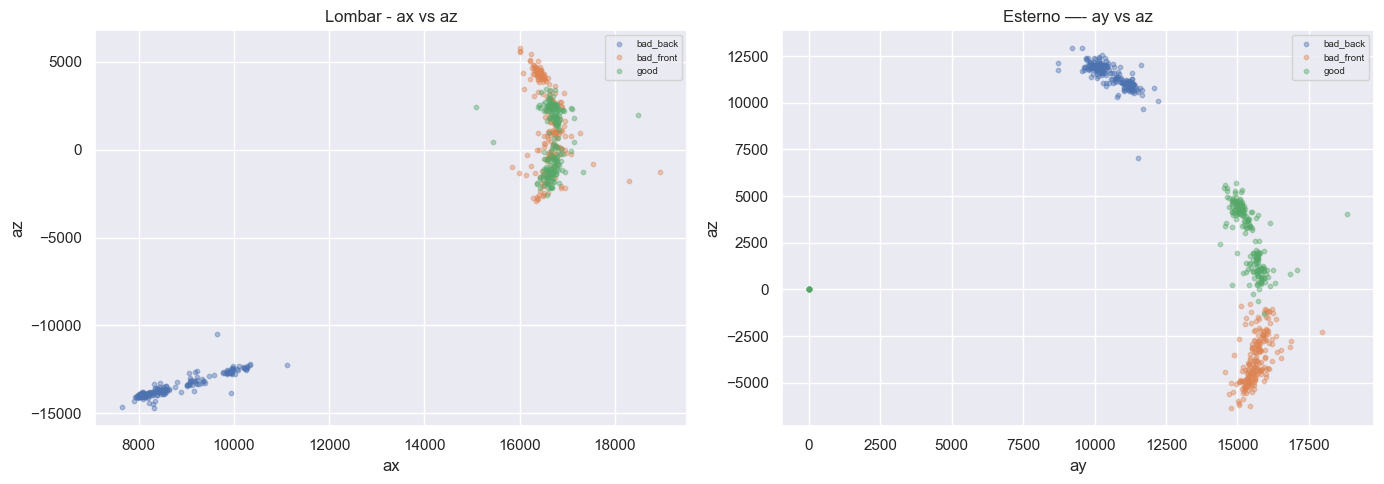

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# lombar: ax vs az
for label in sorted(lombar["label"].unique()):
    subset = lombar[lombar["label"] == label].sample(200, random_state=42)
    axes[0].scatter(subset["ax"], subset["az"], label=label, alpha=0.4, s=10)
axes[0].set_title("Lombar - ax vs az")
axes[0].set_xlabel("ax")
axes[0].set_ylabel("az")
axes[0].legend(fontsize=7)

# esterno: ay vs az
for label in sorted(esterno["label"].unique()):
    subset = esterno[esterno["label"] == label].sample(200, random_state=42)
    axes[1].scatter(subset["ay"], subset["az"], label=label, alpha=0.4, s=10)
axes[1].set_title("Esterno - ay vs az")
axes[1].set_xlabel("ay")
axes[1].set_ylabel("az")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

The scatter plots confirm and extend the findings from the violin plots.

**Lombar - ax vs az:**
`bad_back` forms a completely isolated cluster in the bottom-left region
(ax ~8,000–10,500, az ~-12,500 to -15,000), with no overlap with any other class.
Leaning back produces a fundamentally different gravity projection on the lombar sensor.

`bad_front` and `good` cluster tightly together in the right region (ax ~16,000–18,000),
with significant overlap. No separation is visible between these two classes in this
2D space.

**Esterno - ay vs az:**
`bad_back` is again isolated (ay ~10,000, az ~10,000–12,500), well separated from the
other two classes. `bad_front` and `good` share the same ay range (~15,000–16,000) but
separate along az: `bad_front` clusters at negative az (~-2,500 to -5,000) and `good`
at positive az (~2,500 to 5,000). This is the clearest 2D separation between these two
classes observed in the dataset.

**Overall:** `bad_back` is trivially separable in 2D accelerometer space on both nodes.
`bad_front` vs `good` requires the esterno `az` axis and likely temporal context for
reliable separation.

### 3.7 Statistical Summary per Class

A statistical summary of each feature grouped by class provides a quantitative basis
for the observations made in the previous sections. Mean and standard deviation per
class and feature allow us to formally document the separability of each class and
identify which features are most stable within a class. A low standard deviation
indicates consistent sensor readings, which is desirable for a static posture detector.

In [13]:
features = ["ax", "ay", "az", "gx", "gy", "gz"]

for node, node_data in [("lombar", lombar), ("esterno", esterno)]:
    print(f"\n{'='*60}")
    print(f"Node: {node.upper()}")
    print(f"{'='*60}")
    summary = node_data.groupby("label")[features].agg(["mean", "std"]).round(1)
    display(summary)


Node: LOMBAR


ax             ay               az             gx          \
              mean    std    mean     std     mean     std   mean     std   
label                                                                       
bad_back    8810.8  816.9 -1166.4  1115.0 -13476.2   669.3   97.5   318.2   
bad_front  16585.5  312.9   271.9   865.2   1337.2  2314.0  102.6  1396.2   
good       16673.1  223.4  -264.3   686.0    708.9  1765.0   67.7   759.6   

              gy            gz         
            mean    std   mean    std  
label                                  
bad_back  -307.8  473.8  330.1  257.1  
bad_front -281.9  566.8  336.2  623.1  
good      -259.3  364.2  341.5  270.5


Node: ESTERNO


ax              ay               az             gx         \
             mean    std     mean     std     mean     std   mean    std   
label                                                                      
bad_back   2762.1  653.8  10550.9   654.7  11499.4   711.6 -152.7  516.0   
bad_front  1485.5  940.9  15600.2   446.5  -3756.3  1273.1 -157.6  761.7   
good       2298.8  716.7  14988.3  2665.4   2561.3  1699.4 -155.2  446.6   

              gy            gz         
            mean     std  mean    std  
label                                  
bad_back   185.0   539.1   9.6  339.6  
bad_front  167.5  1376.8   1.5  690.6  
good        96.2   817.9 -19.5  481.4

The statistical summary confirms and quantifies the patterns observed in the previous sections.

**Lombar node:**

`ax` is the most discriminative feature: `bad_back` has a mean of ~8,811 (±817), clearly
separated from `bad_front` (~16,586 ±313) and `good` (~16,673 ±223). The low standard
deviation of all three classes on `ax` makes it the single most reliable feature on this node.

`az` reinforces this: `bad_back` shows a mean of ~-13,476 (±669), while `bad_front`
(~1,337 ±2,314) and `good` (~709 ±1,765) are both near-zero. The high standard deviation
of `bad_front` and `good` on `az` confirms the overlap seen in the violin plots.

Gyroscope features show low means near zero across all classes with high standard deviations,
confirming low individual discriminative power.

**Esterno node:**

`az` is the strongest three-way discriminator: `bad_back` (~11,499 ±712), `good`
(~2,561 ±1,699), and `bad_front` (~-3,756 ±1,273) show a clear ordering with no
overlapping intervals — the only feature where all three classes are meaningfully separated.

`ay` separates `bad_back` (~10,551 ±655) clearly from `bad_front` (~15,600 ±447) and
`good` (~14,988 ±2,665). The high standard deviation of `good` on `ay` (±2,665 vs ±447
for `bad_front`) suggests higher variability in chest orientation during correct posture.

**Overall:** The accelerometer features, particularly `ax` and `az` on the lombar node
and `az` on the esterno node, provide strong class separation. Esterno `az` is the only
feature that meaningfully separates all three classes simultaneously.

## 4. Preprocessing

Raw data from two independent nodes must be transformed into a format suitable for model
training. Each row currently represents a single sensor reading from one node. The model
requires a single feature vector combining both nodes, segmented into fixed-length time windows.

To enable an honest evaluation, each window keeps a reference to its source recording session, so that windows from the same session are never split between training and test sets.


This section covers four steps:

1. **Merge** - pair each lombar sample with its closest esterno sample by time
2. **Windowing** - segment the continuous signal into fixed-length windows
3. **Normalization** - scale features to a common range
4. **Encoding** - convert string labels to integers

### 4.1 Merge Lombar and Esterno


Since both nodes sample independently, we use `t_ms` to pair each lombar reading with the temporally closest esterno reading within the same session, using a nearest-neighbor merge. Merging per session (rather than per class) avoids aligning timestamps from different recordings, since each device resets its clock at the start of every session. The result is a single row with 12 features (6 per node) representing the combined posture state at each point in time.

In [14]:
from pandas import merge_asof

features = ["ax", "ay", "az", "gx", "gy", "gz"]
merged_dfs = []

lombar  = data[data["node"] == "lombar"]
esterno = data[data["node"] == "esterno"]

for session in sorted(data["session"].unique()):
    l = lombar[lombar["session"] == session].sort_values("t_ms").reset_index(drop=True)
    e = esterno[esterno["session"] == session].sort_values("t_ms").reset_index(drop=True)

    if len(l) == 0 or len(e) == 0:
        continue

    label = l["label"].iloc[0]

    l = l[["t_ms"] + features].rename(columns={f: f"{f}_lmb" for f in features})
    e = e[["t_ms"] + features].rename(columns={f: f"{f}_est" for f in features})

    merged = merge_asof(l, e, on="t_ms", direction="nearest")
    merged["label"] = label
    merged["session"] = session   # <-- mantém a sessão
    merged_dfs.append(merged)

merged_data = pd.concat(merged_dfs, ignore_index=True)

print(f"Merged rows:    {merged_data.shape[0]}")
print(f"Merged columns: {merged_data.shape[1]}")
print(f"Sessions:       {merged_data['session'].nunique()}")
merged_data.head()

Merged rows:    24781
Merged columns: 15
Sessions:       25


,t_ms,ax_lmb,ay_lmb,az_lmb,gx_lmb,gy_lmb,gz_lmb,ax_est,ay_est,az_est,gx_est,gy_est,gz_est,label,session
0,979809,9524,-1744,-12920,-277,-243,417,1780,10004,12360,466,78,-462,bad_back,seated_bad_back/bbs1.csv
1,979831,9488,-1680,-12908,-324,-189,439,1780,10004,12360,466,78,-462,bad_back,seated_bad_back/bbs1.csv
2,979853,9536,-1816,-13124,-335,-296,382,1780,10004,12360,466,78,-462,bad_back,seated_bad_back/bbs1.csv
3,979875,9468,-1740,-13360,-207,-242,544,1780,10004,12360,466,78,-462,bad_back,seated_bad_back/bbs1.csv
4,979897,9336,-1932,-13164,-165,-284,561,1780,10004,12360,466,78,-462,bad_back,seated_bad_back/bbs1.csv


The merge produced **24,781 rows**, one per lombar sample, each paired with the nearest
esterno reading. The 15 columns consist of `t_ms`, `label`, `session`, and 12 IMU features
(6 per node).
One issue is visible in the first 5 rows: the esterno values are identical across rows 0–4
(`ax_est=1780`, `ay_est=10004`, etc.). This occurs because the nearest esterno sample for
multiple consecutive lombar readings is the same, a consequence of the two nodes not being
perfectly synchronized. At 50Hz with ~20ms between samples, this is expected and acceptable
for static posture classification where the signal changes slowly.

### 4.2 Windowing

Rather than treating each row as an independent sample, we segment the signal into fixed-length overlapping windows. Each window captures 2 seconds of data (100 samples at 50Hz) and is assigned the label of its source session.

Windows are generated per session, so a window never crosses the boundary between two recordings. Each window also keeps a reference to its source session, which is later used to keep all windows from the same session within the same fold.

A 50% overlap (stride of 50 samples) is used to increase the number of training samples without collecting additional data. The overlap is safe because overlapping windows always belong to the same session and are therefore never split between training and test sets.

In [16]:
WINDOW_SIZE = 100  # 2s at 50Hz
STRIDE = 50   # 50% overlap

feature_cols = [c for c in merged_data.columns if c not in ["t_ms", "label", "session"]]

X, y, groups = [], [], []

for session in sorted(merged_data["session"].unique()):
    sdf = merged_data[merged_data["session"] == session]
    subset = sdf[feature_cols].values
    label = sdf["label"].iloc[0]

    for start in range(0, len(subset) - WINDOW_SIZE + 1, STRIDE):
        window = subset[start:start + WINDOW_SIZE]
        X.append(window)
        y.append(label)
        groups.append(session)   # <-- de que sessão veio esta janela

X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print(f"Windows:  {X.shape[0]}")
print(f"Shape:    {X.shape}  (windows, timesteps, features)")
print(f"\nLabel distribution:")
for label in np.unique(y):
    print(f"  {label:25s}: {np.sum(y == label)}")
print(f"\nWindows per session (primeiras 5):")
for s in sorted(np.unique(groups))[:5]:
    print(f"  {s}: {np.sum(groups == s)}")

Windows:  457
Shape:    (457, 100, 12)  (windows, timesteps, features)

Label distribution:
  bad_back                 : 89
  bad_front                : 189
  good                     : 179

Windows per session (primeiras 5):
  seated_bad_back/bbs1.csv: 17
  seated_bad_back/bbs2.csv: 18
  seated_bad_back/bbs3.csv: 18
  seated_bad_back/bbs4.csv: 18
  seated_bad_back/bbs5.csv: 18


The windowing step produced 457 windows, each of shape (100, 12), 100 timesteps and 12
features. The distribution across classes is: `bad_front` (189), `good` (179), `bad_back`
(89). `bad_back` has roughly half the windows of the other two, a direct consequence of
it representing a single original class while the others merged two.

457 windows is a modest dataset. This is a known constraint of the collection setup — 5
sessions of ~20 seconds per class yields limited data after windowing. This will be taken
into account when selecting and evaluating the model, particularly since each session must
be kept intact within a single fold, leaving few sessions per split.

### 4.3 Normalization

Raw IMU values are in LSB units with ranges that vary significantly across features (e.g. `ax_lmb` ~8,000–18,000 vs `gz_est` ~-4,000–4,000). Without normalization, features with larger magnitudes dominate the model. We apply StandardScaler (zero mean, unit variance) fitted only on the training set to prevent data leakage.

Normalization is applied within each cross-validation fold (section 4.4), with the scaler fitted on the training sessions only.

### 4.4 Label Encoding and Cross-Validation Setup

String labels are converted to integers using `LabelEncoder`. Given the modest size of the dataset (457 windows), a single train/test split would produce an unreliable estimate of model performance, so a statistically more robust evaluation is required.

A standard Stratified K-Fold split cannot be used here. Because windows overlap by 50% and multiple windows originate from the same recording session, assigning windows to folds at random would place near-identical windows in both the training and test sets. The model would then be evaluated on data almost identical to what it trained on, producing artificially perfect scores that do not reflect real-world performance.

To prevent this, we use **Stratified Group K-Fold Cross-Validation** with k=5, using the source session as the grouping variable. This guarantees that all windows from a given session stay within a single fold: the model is always tested on sessions it has never seen during training, which mirrors the real deployment scenario of classifying a new recording. The stratification still preserves class balance across folds. We report the mean and standard deviation of accuracy over the 5 folds.

The `StandardScaler` is fitted independently within each fold on the training set only, preventing leakage of feature statistics from the test set.

In [18]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

N_SPLITS = 5
skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

n_classes  = len(le.classes_)
n_features = X.shape[2]
n_steps    = X.shape[1]

print(f"\nWindows:   {X.shape[0]}")
print(f"Classes:   {n_classes}")
print(f"Features:  {n_features}")
print(f"Timesteps: {n_steps}")
print(f"Folds:     {N_SPLITS}")

# verificação: confirmar que nenhuma sessão aparece em treino E teste
print("\nLeakage verification (shared sessions train/test):")
for fold_idx, (tr, te) in enumerate(skf.split(X, y_enc, groups)):
    sessoes_treino = set(groups[tr])
    sessoes_teste = set(groups[te])
    overlap = sessoes_treino & sessoes_teste
    print(f"  Fold {fold_idx+1}: {len(overlap)} shared sessions (has to be 0)")

Label mapping:
  0 → bad_back
  1 → bad_front
  2 → good

Windows:   457
Classes:   3
Features:  12
Timesteps: 100
Folds:     5

Leakage verification (shared sessions train/test):
  Fold 1: 0 shared sessions (has to be 0)
  Fold 2: 0 shared sessions (has to be 0)
  Fold 3: 0 shared sessions (has to be 0)
  Fold 4: 0 shared sessions (has to be 0)
  Fold 5: 0 shared sessions (has to be 0)


The label encoder assigned integer indices in alphabetical order: `0 → bad_back`,
`1 → bad_front`, `2 → good`. The dataset of 457 windows is divided into 5 folds by
source session, so each fold contains whole sessions rather than a fixed number of windows.
On average this leaves roughly 4 sessions per class for training and 1 for testing in each
fold (about 365 windows for training and 92 for testing), with class distribution preserved
through stratification.

The scaler is fitted independently within each fold to prevent data leakage.

The data is now ready for model training.

## 5. Model Training

We evaluate three models to establish a performance baseline before committing to a
deployable architecture.

**Random Forest** and **SVM** are trained on statistical features extracted from each
window (mean, std, min, max per feature → 48 features). These models cannot be deployed
to the ESP32 but serve as an upper-bound reference: if the CNN matches their performance,
the architecture is sufficient; if it falls significantly short, the bottleneck is data,
not model choice.

**1D CNN** is trained directly on the raw windowed signal (100 timesteps × 12 features).
It is the only model exported to TFLite for ESP32 deployment. The architecture is
intentionally compact to fit within the ESP32's ~520KB SRAM after quantization.

All models are evaluated using the same Stratified Group K-Fold split (k=5) to ensure
a fair comparison.

### 5.1 Random Forest

Random Forest is an ensemble of decision trees trained on random subsets of features and
samples. It is robust with small datasets, requires no normalization, and is interpretable
via feature importance. It serves as the primary baseline.

Hyperparameters are tuned using `RandomizedSearchCV` with 50 iterations over the same
Stratified Group K-Fold split used for evaluation, ensuring no session leakage during
tuning.

In [19]:
import numpy as np

def extrair_features(X):
    feats = []
    for window in X:
        f = np.concatenate([
            window.mean(axis=0),
            window.std(axis=0),
            window.min(axis=0),
            window.max(axis=0),
        ])
        feats.append(f)
    return np.array(feats)

X_feat = extrair_features(X)
print(f"Shape: {X_feat.shape}  (windows, features)")

Shape: (457, 48)  (windows, features)


In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search.fit(X_feat, y_enc, groups=groups)

print(f"\Best accuracy (CV): {search.best_score_:.4f}")
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
\Best accuracy (CV): 1.0000
Best parameters:
  criterion: gini
  max_depth: 30
  max_features: sqrt
  min_samples_leaf: 3
  min_samples_split: 4
  n_estimators: 171


`RandomizedSearchCV` evaluated 50 parameter combinations over 5 folds (250 fits total).
The best cross-validated accuracy was **1.0000**, achieved with the following parameters:
`criterion=gini`, `max_depth=30`, `max_features=sqrt`, `min_samples_leaf=3`,
`min_samples_split=4`, `n_estimators=171`.

A perfect CV score with this dataset size is expected: the sessions are recorded by a
small number of subjects under controlled conditions, so the model learns subject-specific
movement patterns rather than generalizable posture features. This is a known limitation
of the data collection setup and is discussed further in the results section.

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

rf_best = RandomForestClassifier(**search.best_params_, random_state=42, n_jobs=-1)

y_true_all, y_pred_all = [], []
for train_idx, test_idx in skf.split(X_feat, y_enc, groups):
    rf_best.fit(X_feat[train_idx], y_enc[train_idx])
    y_true_all.extend(y_enc[test_idx])
    y_pred_all.extend(rf_best.predict(X_feat[test_idx]))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

print("Classification Report (RF):\n")
print(classification_report(y_true_all, y_pred_all, target_names=le.classes_, digits=3))

cm = confusion_matrix(y_true_all, y_pred_all)
print("\nConfusion Matrix:")
print(f"{'':20s}" + "".join(f"{c:>10s}" for c in le.classes_))
for i, c in enumerate(le.classes_):
    print(f"{c:20s}" + "".join(f"{cm[i][j]:>10d}" for j in range(len(le.classes_))))

Classification Report (RF):

              precision    recall  f1-score   support

    bad_back      1.000     1.000     1.000        89
   bad_front      1.000     1.000     1.000       189
        good      1.000     1.000     1.000       179

    accuracy                          1.000       457
   macro avg      1.000     1.000     1.000       457
weighted avg      1.000     1.000     1.000       457


Confusion Matrix:
                      bad_back bad_front      good
bad_back                    89         0         0
bad_front                    0       189         0
good                         0         0       179


The optimized Random Forest achieves **1.000 accuracy** across all three classes with zero
misclassifications. Every `bad_back`, `bad_front`, and `good` window is correctly classified.

As noted above, this result reflects the homogeneity of the dataset rather than true
generalization.

### 5.2 Support Vector Machine

SVM is evaluated as a second baseline. It is trained on the same `X_feat` statistical
features and uses the same Stratified Group K-Fold split. Hyperparameters are tuned with
`RandomizedSearchCV` (50 iterations).

In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

param_dist = {
    "C": loguniform(0.1, 1000),
    "gamma": loguniform(1e-4, 1),
    "kernel": ["rbf", "poly"],
    "degree": [2, 3, 4],  # só usado com poly
}

search_svm = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search_svm.fit(X_feat, y_enc, groups=groups)

print(f"\nBest accuracy (CV): {search_svm.best_score_:.4f}")
print("Best parameters:")
for k, v in search_svm.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best accuracy (CV): 1.0000
Best parameters:
  C: 3.14891164795686
  degree: 2
  gamma: 0.000541675458324746
  kernel: poly


`RandomizedSearchCV` evaluated 50 combinations over 5 folds (250 fits total). Best
CV accuracy: **1.0000**, with `kernel=poly`, `C=3.149`, `gamma=0.000542`, `degree=2`.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

svm_best = SVC(**search_svm.best_params_, random_state=42)

y_true_svm, y_pred_svm = [], []
for train_idx, test_idx in skf.split(X_feat, y_enc, groups):
    svm_best.fit(X_feat[train_idx], y_enc[train_idx])
    y_true_svm.extend(y_enc[test_idx])
    y_pred_svm.extend(svm_best.predict(X_feat[test_idx]))

y_true_svm = np.array(y_true_svm)
y_pred_svm = np.array(y_pred_svm)

print("Classification Report (SVM):\n")
print(classification_report(y_true_svm, y_pred_svm, target_names=le.classes_, digits=3))

cm_svm = confusion_matrix(y_true_svm, y_pred_svm)
print("\nConfusion Matrix:")
print(f"{'':20s}" + "".join(f"{c:>10s}" for c in le.classes_))
for i, c in enumerate(le.classes_):
    print(f"{c:20s}" + "".join(f"{cm_svm[i][j]:>10d}" for j in range(len(le.classes_))))

Classification Report (SVM):

              precision    recall  f1-score   support

    bad_back      1.000     1.000     1.000        89
   bad_front      1.000     1.000     1.000       189
        good      1.000     1.000     1.000       179

    accuracy                          1.000       457
   macro avg      1.000     1.000     1.000       457
weighted avg      1.000     1.000     1.000       457


Confusion Matrix:
                      bad_back bad_front      good
bad_back                    89         0         0
bad_front                    0       189         0
good                         0         0       179


The SVM achieves **1.000 accuracy**, identical to the Random Forest. Zero misclassifications
across all three classes.

### 5.3 1D Convolutional Neural Network

The CNN operates directly on the raw windowed signal (100 timesteps × 12 features),
without manual feature extraction. The architecture is intentionally compact:

In [25]:
def build_model(n_steps, n_features, n_classes):
    """
    Compact 1D CNN for posture classification.

    Architecture:
        Conv1D(32, 5) → Conv1D(64, 3) → GlobalAveragePooling1D →
        Dense(32) → Dropout(0.3) → Dense(n_classes, softmax)

    GlobalAveragePooling1D is used instead of Flatten to drastically
    reduce parameter count, which is critical for ESP32 deployment.
    """
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=5, activation="relu",
                      input_shape=(n_steps, n_features)),
        layers.Conv1D(64, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_preview = build_model(n_steps, n_features, n_classes)
model_preview.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 96, 32)         │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,339 (40.39 KB)

 Trainable params: 10,339 (40.39 KB)

 Non-trainable params: 0 (0.00 B)

### 5.3.2 Cross-Validation Training

The CNN is trained independently for each fold. Early stopping (patience=10 on val_loss)
prevents overfitting within each fold. The scaler is fitted on the training fold only.

In [26]:
EPOCHS = 100
BATCH_SIZE = 16

fold_accuracies = []
fold_histories = []
all_y_true = []
all_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y_enc, groups)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold_idx + 1}/{skf.n_splits}")
    print(f"{'='*50}")

    # split
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    # normalize — fit on train only
    scaler = StandardScaler()
    n_samples_train, n_timesteps, n_feat = X_train.shape
    X_train_flat = X_train.reshape(-1, n_feat)
    X_test_flat = X_test.reshape(-1, n_feat)

    scaler.fit(X_train_flat)
    X_train = scaler.transform(X_train_flat).reshape(n_samples_train, n_timesteps, n_feat)
    X_test = scaler.transform(X_test_flat).reshape(len(X_test), n_timesteps, n_feat)

    # build fresh model for each fold
    model = build_model(n_steps, n_feat, n_classes)

    # early stopping
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    # train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    # evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    fold_accuracies.append(acc)
    fold_histories.append(history)

    # predictions for confusion matrix
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  Stopped at epoch: {len(history.history['loss'])}")

print(f"\n{'='*50}")
print(f"CROSS-VALIDATION RESULTS")
print(f"{'='*50}")
print(f"  Mean accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"  Per fold:      {[f'{a:.4f}' for a in fold_accuracies]}")


FOLD 1/5
  Accuracy: 0.3684
  Stopped at epoch: 11

FOLD 2/5
  Accuracy: 1.0000
  Stopped at epoch: 35

FOLD 3/5
  Accuracy: 0.7872
  Stopped at epoch: 13

FOLD 4/5
  Accuracy: 1.0000
  Stopped at epoch: 23

FOLD 5/5
  Accuracy: 0.6000
  Stopped at epoch: 13

CROSS-VALIDATION RESULTS
  Mean accuracy: 0.7511 ± 0.2427
  Per fold:      ['0.3684', '1.0000', '0.7872', '1.0000', '0.6000']


The CNN achieves **0.751 ± 0.243** mean accuracy. The standard deviation of 0.243 is the
key finding> two folds reach 1.000 while two others fall below 0.600. This is not
random noise: it reflects which sessions land in the test fold. When the test fold
contains sessions similar to the training set, the model performs perfectly; when it
contains a divergent session, performance collapses.

This confirms that the CNN is learning session-specific patterns rather than generalizable
posture features, being this a direct consequence of the small number of subjects in the dataset.
The RF and SVM baselines showed the same ceiling effect but are less sensitive to it due
to their use of hand-crafted statistical features.

### 5.3.3 Training Curves

We plot the accuracy and loss curves for each fold to check for
overfitting. Healthy training shows the train and validation curves
converging. A large gap indicates overfitting.

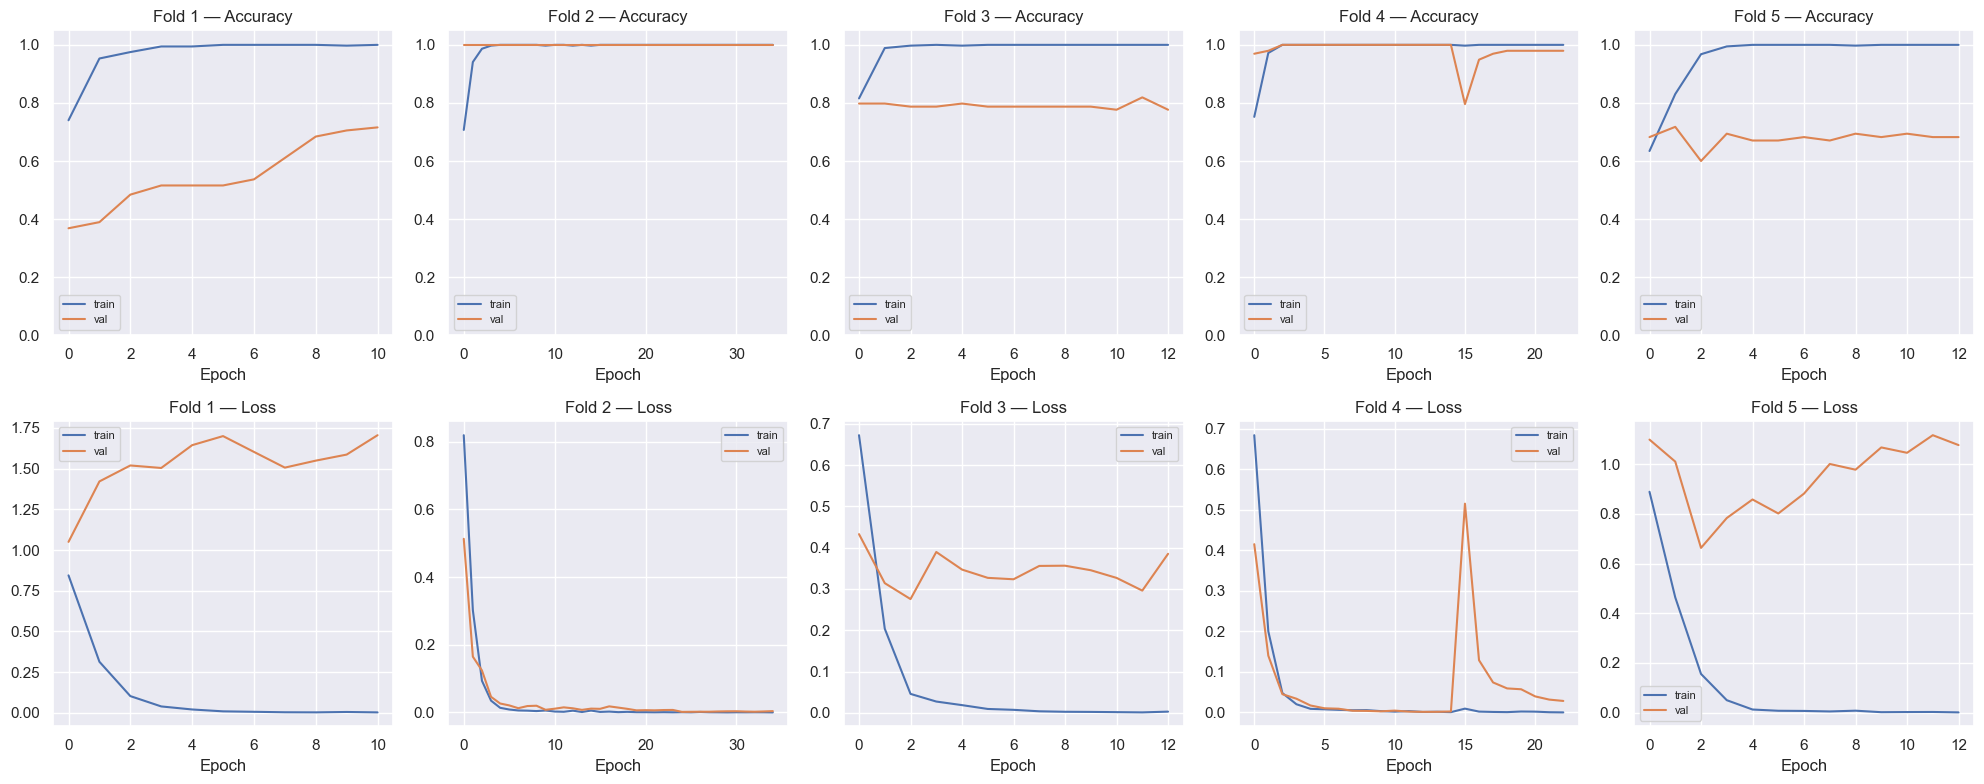

In [27]:
fig, axes = plt.subplots(2, skf.n_splits, figsize=(20, 8))

for i, history in enumerate(fold_histories):
    # accuracy
    axes[0, i].plot(history.history["accuracy"], label="train")
    axes[0, i].plot(history.history["val_accuracy"], label="val")
    axes[0, i].set_title(f"Fold {i+1} — Accuracy")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_ylim([0, 1.05])
    axes[0, i].legend(fontsize=8)

    # loss
    axes[1, i].plot(history.history["loss"], label="train")
    axes[1, i].plot(history.history["val_loss"], label="val")
    axes[1, i].set_title(f"Fold {i+1} — Loss")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.show()

The training curves confirm the fold-to-fold instability. In Folds 2 and 4, training and
validation accuracy converge to 1.000 — the model generalizes perfectly to those test
sessions. In Folds 1, 3, and 5, the train-val gap is large and persistent: training loss
reaches near-zero while validation loss stagnates or increases, a clear sign of overfitting
to the training sessions.

Early stopping triggered between epoch 11 and 35 across folds, with no consistent
convergence pattern, further evidence that performance is driven by session composition
rather than model capacity.

### 5.3.4 Confusion Matrix

The aggregated confusion matrix combines predictions from all 5 folds.
Each sample appears exactly once as a test sample across the folds.
This gives a complete picture of model performance without data leakage.

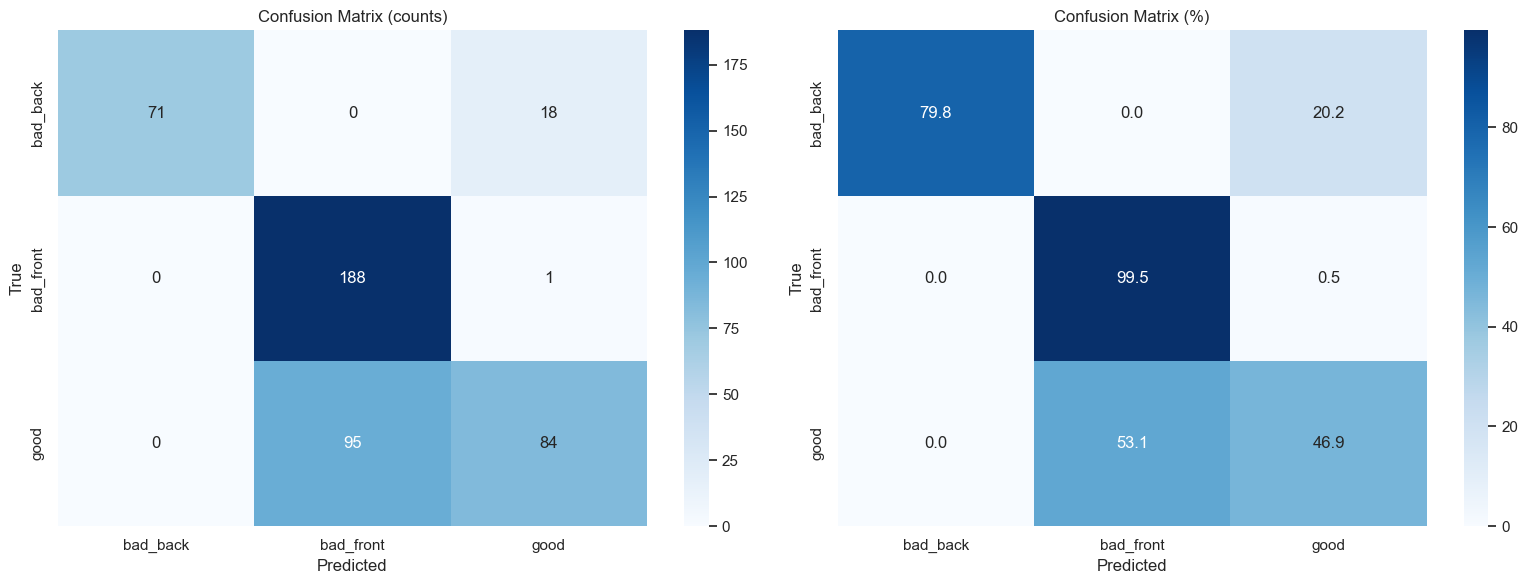

Classification Report (aggregated across all folds):

              precision    recall  f1-score   support

    bad_back      1.000     0.798     0.887        89
   bad_front      0.664     0.995     0.797       189
        good      0.816     0.469     0.596       179

    accuracy                          0.751       457
   macro avg      0.827     0.754     0.760       457
weighted avg      0.789     0.751     0.736       457



In [30]:
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

cm = confusion_matrix(all_y_true, all_y_pred)
cm_pct = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# absolute counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# percentages
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Confusion Matrix (%)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

print("Classification Report (aggregated across all folds):\n")
print(classification_report(
    all_y_true, all_y_pred,
    target_names=le.classes_,
    digits=3
))

## 6. Export to TFLite

The final model is trained on the complete dataset (all 457 windows) and exported to
TFLite with full int8 quantization for ESP32 deployment.

Three files are generated:
- `posture_model.tflite` the quantized model
- `model.h` C array header for inclusion in the Arduino sketch
- `deploy_params.json` quantization parameters and scaler statistics needed to
  normalize sensor input on the ESP32 at inference time

### 6.1 Train Final Model and Convert

The scaler is fitted on all data. The model is trained for 30 epochs without early
stopping. No validation set is held out since this model is for deployment, not evaluation.

In [31]:
import tensorflow as tf
import numpy as np
import os

output_dir = "./model_export"
os.makedirs(output_dir, exist_ok=True)

# 1. normalize data
scaler_final = StandardScaler()
X_flat = X.reshape(-1, n_features)
scaler_final.fit(X_flat)
X_norm = scaler_final.transform(X_flat).reshape(X.shape)

# 2. train FINAL model in all data (to deploy)
final_model = build_model(n_steps, n_features, n_classes)
final_model.fit(X_norm, y_enc, epochs=30, batch_size=16, verbose=1)

# 3. representative dataset to calibrate int8 quant
def representative_dataset():
    for i in range(len(X_norm)):
        yield [X_norm[i:i+1].astype(np.float32)]

# 4. convert to tflite with the completed int8 quant
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

tflite_path = os.path.join(output_dir, "posture_model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Modelo guardado: {tflite_path}")
print(f"Tamanho: {len(tflite_model) / 1024:.1f} KB")

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7090 - loss: 0.6864 
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9519 - loss: 0.2192
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9956 - loss: 0.0461
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0137
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0079
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0033   
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0045
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0016
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0037
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 7.1721e-04
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0032   
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 

INFO:tensorflow:Assets written to: C:\Users\JOSEM~1.SOU\AppData\Local\Temp\tmpg5y6sywz\assets


Saved artifact at 'C:\Users\JOSEM~1.SOU\AppData\Local\Temp\tmpg5y6sywz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 12), dtype=tf.float32, name='keras_tensor_42')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2322854038512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2322854414816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2322854419920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2322854416224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2322854418864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2322854419040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2322854417104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2322854421856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modelo guardado: ./model_export\posture_model.tflite
Tamanho: 18.9 KB


### 6.2 Generate Deploy Files

Extract quantization parameters and scaler statistics required by the ESP32 sketch,
and generate the C header array.

In [32]:
import json

# A) generate C .h with the model
c_array_path = os.path.join(output_dir, "model.h")
with open(tflite_path, "rb") as f:
    tflite_bytes = f.read()

with open(c_array_path, "w") as f:
    f.write("#ifndef MODEL_H\n#define MODEL_H\n\n")
    f.write(f"const unsigned int model_tflite_len = {len(tflite_bytes)};\n")
    f.write("alignas(8) const unsigned char model_tflite[] = {\n")
    for i, b in enumerate(tflite_bytes):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"0x{b:02x}, ")
        if i % 12 == 11:
            f.write("\n")
    f.write("\n};\n\n#endif\n")

print(f"Header C guardado: {c_array_path}")

# B) extrair parâmetros de quantização
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

in_scale, in_zp   = input_details["quantization"]
out_scale, out_zp = output_details["quantization"]

print("\n=== QUANT PARAMETERS ===")
print(f"Input  scale:      {in_scale}")
print(f"Input  zero_point: {in_zp}")
print(f"Output scale:      {out_scale}")
print(f"Output zero_point: {out_zp}")

# C) store scaler and parameters
np.set_printoptions(precision=6, suppress=True)
print(f"\n=== NORMALIZATION (StandardScaler) ===")
print(f"Mean: {scaler_final.mean_}")
print(f"Std:  {scaler_final.scale_}")

params = {
    "input_scale":      float(in_scale),
    "input_zero_point": int(in_zp),
    "output_scale":     float(out_scale),
    "output_zero_point":int(out_zp),
    "scaler_mean":      scaler_final.mean_.tolist(),
    "scaler_std":       scaler_final.scale_.tolist(),
    "labels":           le.classes_.tolist(),
}
with open(os.path.join(output_dir, "deploy_params.json"), "w") as f:
    json.dump(params, f, indent=2)

print(f"\nParâmetros guardados em deploy_params.json")

Header C guardado: ./model_export\model.h

=== QUANT PARAMETERS ===
Input  scale:      0.09173505753278732
Input  zero_point: -3
Output scale:      0.00390625
Output zero_point: -128

=== NORMALIZATION (StandardScaler) ===
Mean: [15101.760613  -214.947396 -1801.342407    86.83628   -271.902451
   335.995077  1836.087527 13667.80744   1767.886214  -134.170678
   184.851204   -67.514223]
Std:  [3128.989625 1005.776162 6055.11331  1030.515671  471.947376  456.084918
  998.206247 3968.598815 5628.089728  284.687593  481.395959  306.142571]

Parâmetros guardados em deploy_params.json


The exported model requires two sets of parameters to run correctly on the ESP32:

**Quantization parameters** used to convert float32 sensor input to int8 before
inference, and int8 output back to probabilities:
- Input: scale=0.0917, zero_point=-3
- Output: scale=0.00391, zero_point=-128

**Scaler parameters** the StandardScaler mean and std per feature, applied to raw
IMU values before quantization. These 12 values (one per feature) must be hardcoded
in the ESP32 sketch.

All parameters are saved to `deploy_params.json` for reference. The model weighs
**18.9 KB**, well within the ESP32's flash capacity.

## 7. Fine Tuning

The cross-validation results showed high variance (0.751 ± 0.243), driven primarily by
the small dataset size and limited subject diversity. This section explores techniques
to improve CNN generalization without collecting additional data.

Three approaches are tested sequentially, each evaluated with the same Stratified Group
K-Fold setup used in section 5:

1. **Data augmentation** artificially increase dataset diversity by adding Gaussian
   noise and time shifting to existing windows
2. **Architecture improvements** Batch Normalization, L2 regularization, increased Dropout
3. **Combined** best augmentation + best architecture together

The baseline to beat: **0.751 ± 0.243**

### 7.1 Data Augmentation - Gaussian Noise

Gaussian noise is added to each window to simulate sensor variability between sessions
and subjects. Augmentation is applied **inside each fold** on the training set only to prevent leakage.

Two copies of each training window are generated with noise scaled to 5% of the global
signal standard deviation, tripling the effective training set size.

In [33]:
def augment_noise(X_train, y_train, noise_factor=0.05, n_copies=2):
    X_aug = [X_train]
    y_aug = [y_train]
    for _ in range(n_copies):
        noise = np.random.normal(0, noise_factor * X_train.std(), X_train.shape)
        X_aug.append(X_train + noise)
        y_aug.append(y_train)
    return np.concatenate(X_aug), np.concatenate(y_aug)


EPOCHS = 100
BATCH_SIZE = 16

aug_accuracies = []
aug_y_true = []
aug_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y_enc, groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    # normalize — fit on train only
    scaler = StandardScaler()
    n_samples_train, n_timesteps, n_feat = X_train.shape
    scaler.fit(X_train.reshape(-1, n_feat))
    X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples_train, n_timesteps, n_feat)
    X_test  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(len(X_test), n_timesteps, n_feat)

    # augmentation on training only
    X_train_aug, y_train_aug = augment_noise(X_train, y_train, noise_factor=0.05, n_copies=2)

    model = build_model(n_steps, n_feat, n_classes)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=0
    )

    model.fit(
        X_train_aug, y_train_aug,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    aug_accuracies.append(acc)

    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    aug_y_true.extend(y_test)
    aug_y_pred.extend(y_pred)

    print(f"Fold {fold_idx+1}: {acc:.4f}")

print(f"\n{'='*50}")
print(f"AUGMENTATION (Gaussian Noise) - RESULTS")
print(f"{'='*50}")
print(f"  Baseline:  0.7511 ± 0.2427")
print(f"  Augmented: {np.mean(aug_accuracies):.4f} ± {np.std(aug_accuracies):.4f}")

aug_y_true = np.array(aug_y_true)
aug_y_pred = np.array(aug_y_pred)

print(f"\nClassification Report (Gaussian Noise Augmentation):\n")
print(classification_report(aug_y_true, aug_y_pred, target_names=le.classes_, digits=3))

Fold 1: 0.7263
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 0.8118

AUGMENTATION (Gaussian Noise) - RESULTS
  Baseline:  0.7511 ± 0.2427
  Augmented: 0.9076 ± 0.1163

Classification Report (Gaussian Noise Augmentation):

              precision    recall  f1-score   support

    bad_back      0.881     1.000     0.937        89
   bad_front      0.863     1.000     0.926       189
        good      1.000     0.765     0.867       179

    accuracy                          0.908       457
   macro avg      0.915     0.922     0.910       457
weighted avg      0.920     0.908     0.905       457



### 7.1.1 Results - Gaussian Noise Augmentation

| | Baseline | Augmented |
|---|---|---|
| Mean accuracy | 0.751 | **0.908** |
| Std | 0.243 | **0.116** |

Gaussian noise augmentation produces a significant improvement on both metrics. Tripling
the training set with noisy copies forces the model to learn posture-invariant features
rather than session-specific patterns, reducing fold-to-fold instability.

The primary failure mode (`good` misclassified as `bad_front`) improved substantially:
recall on `good` rose from 46.9% to 76.5%. `bad_back` and `bad_front` both reached
perfect recall.

`good` precision remains 1.000, when the model predicts `good`, it is always correct.
The remaining errors are false negatives (`good` predicted as `bad_front`), not false
positives.

### 7.2 Data Augmentation - Gaussian Noise + Time Shifting

Time shifting is added to the augmentation pipeline. Each training window is augmented
with both Gaussian noise and a random temporal shift of up to 10 samples, filled by
repeating the edge value. The training set is now 5× the original size (1 original +
2 noise copies + 2 shift copies).

In [34]:
def augment_noise_and_shift(X_train, y_train, noise_factor=0.05, n_copies=2, max_shift=10):
    X_aug = [X_train]
    y_aug = [y_train]

    # gaussian noise
    for _ in range(n_copies):
        noise = np.random.normal(0, noise_factor * X_train.std(), X_train.shape)
        X_aug.append(X_train + noise)
        y_aug.append(y_train)

    # time shifting
    for _ in range(n_copies):
        shifted = np.zeros_like(X_train)
        for i, window in enumerate(X_train):
            shift = np.random.randint(-max_shift, max_shift)
            if shift > 0:
                shifted[i, shift:] = window[:-shift]
                shifted[i, :shift] = window[0]
            elif shift < 0:
                shifted[i, :shift] = window[-shift:]
                shifted[i, shift:] = window[-1]
            else:
                shifted[i] = window
        X_aug.append(shifted)
        y_aug.append(y_train)

    return np.concatenate(X_aug), np.concatenate(y_aug)


EPOCHS = 100
BATCH_SIZE = 16

aug2_accuracies = []
aug2_y_true = []
aug2_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y_enc, groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    scaler = StandardScaler()
    n_samples_train, n_timesteps, n_feat = X_train.shape
    scaler.fit(X_train.reshape(-1, n_feat))
    X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples_train, n_timesteps, n_feat)
    X_test  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(len(X_test), n_timesteps, n_feat)

    X_train_aug, y_train_aug = augment_noise_and_shift(X_train, y_train, noise_factor=0.05, n_copies=2, max_shift=10)

    model = build_model(n_steps, n_feat, n_classes)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=0
    )

    model.fit(
        X_train_aug, y_train_aug,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    aug2_accuracies.append(acc)

    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    aug2_y_true.extend(y_test)
    aug2_y_pred.extend(y_pred)

    print(f"Fold {fold_idx+1}: {acc:.4f}")

print(f"\n{'='*50}")
print(f"AUGMENTATION (Noise + Shift) - RESULTS")
print(f"{'='*50}")
print(f"  Baseline:       0.7511 ± 0.2427")
print(f"  Noise only:     0.9076 ± 0.1163")
print(f"  Noise + Shift:  {np.mean(aug2_accuracies):.4f} ± {np.std(aug2_accuracies):.4f}")

aug2_y_true = np.array(aug2_y_true)
aug2_y_pred = np.array(aug2_y_pred)

print(f"\nClassification Report (Noise + Shift):\n")
print(classification_report(aug2_y_true, aug2_y_pred, target_names=le.classes_, digits=3))

Fold 1: 0.7158
Fold 2: 1.0000
Fold 3: 0.9362
Fold 4: 1.0000
Fold 5: 0.7529

AUGMENTATION (Noise + Shift) - RESULTS
  Baseline:       0.7511 ± 0.2427
  Noise only:     0.9076 ± 0.1163
  Noise + Shift:  0.8810 ± 0.1225

Classification Report (Noise + Shift):

              precision    recall  f1-score   support

    bad_back      0.767     1.000     0.868        89
   bad_front      0.875     1.000     0.933       189
        good      1.000     0.698     0.822       179

    accuracy                          0.882       457
   macro avg      0.881     0.899     0.875       457
weighted avg      0.903     0.882     0.877       457



### 7.2.1 Results - Gaussian Noise + Time Shifting

| | Baseline | Noise only | Noise + Shift |
|---|---|---|---|
| Mean accuracy | 0.751 | **0.908** | 0.881 |
| Std | 0.243 | **0.116** | 0.123 |

Adding time shifting degraded performance relative to noise only. For static posture
classification, the temporal position of a window within a session carries no meaningful
information. Shifting it introduces artificial patterns that the model cannot generalize
from. Gaussian noise alone remains the best augmentation strategy for this task.

### 7.3 Architecture Improvements

The baseline CNN is augmented with three regularization techniques applied on top of
the best augmentation strategy (Gaussian noise only):

- **Batch Normalization** after each Conv1D - stabilizes activations and acts as implicit regularization
- **L2 regularization** on the Dense layer - penalizes large weights
- **Increased Dropout** from 0.3 to 0.5 - stronger stochastic regularization

All three are tested together as a single improved architecture.

In [36]:
from sklearn.model_selection import train_test_split

EPOCHS = 100
BATCH_SIZE = 16

v2_final_accuracies = []
v2_final_y_true = []
v2_final_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y_enc, groups)):

    # separar validação do treino (sem tocar no test)
    train_idx_inner, val_idx_inner = train_test_split(
        train_idx,
        test_size=0.2,
        random_state=42,
        stratify=y_enc[train_idx]
    )

    X_train = X[train_idx_inner]
    X_val   = X[val_idx_inner]
    X_test  = X[test_idx]
    y_train = y_enc[train_idx_inner]
    y_val   = y_enc[val_idx_inner]
    y_test  = y_enc[test_idx]

    # normalizar — fit apenas no treino
    scaler = StandardScaler()
    n_samples_train, n_timesteps, n_feat = X_train.shape
    scaler.fit(X_train.reshape(-1, n_feat))
    X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples_train, n_timesteps, n_feat)
    X_val   = scaler.transform(X_val.reshape(-1, n_feat)).reshape(len(X_val), n_timesteps, n_feat)
    X_test  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(len(X_test), n_timesteps, n_feat)

    # augmentation apenas no treino
    X_train_aug, y_train_aug = augment_noise(X_train, y_train, noise_factor=0.05, n_copies=2)

    model = build_model_v2(n_steps, n_feat, n_classes)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=0
    )

    model.fit(
        X_train_aug, y_train_aug,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    v2_final_accuracies.append(acc)

    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    v2_final_y_true.extend(y_test)
    v2_final_y_pred.extend(y_pred)

    print(f"Fold {fold_idx+1}: {acc:.4f}")

print(f"\n{'='*50}")
print(f"FINAL MODEL (v2 + proper val split) - RESULTS")
print(f"{'='*50}")
print(f"  Baseline:      0.7511 ± 0.2427")
print(f"  Noise only:    0.9076 ± 0.1163")
print(f"  v2 (leaky):    0.9976 ± 0.0047")
print(f"  v2 (correct):  {np.mean(v2_final_accuracies):.4f} ± {np.std(v2_final_accuracies):.4f}")

v2_final_y_true = np.array(v2_final_y_true)
v2_final_y_pred = np.array(v2_final_y_pred)

print(f"\nClassification Report (Final Model):\n")
print(classification_report(v2_final_y_true, v2_final_y_pred, target_names=le.classes_, digits=3))

Fold 1: 0.7158
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 1.0000

FINAL MODEL (v2 + proper val split) - RESULTS
  Baseline:      0.7511 ± 0.2427
  Noise only:    0.9076 ± 0.1163
  v2 (leaky):    0.9976 ± 0.0047
  v2 (correct):  0.9432 ± 0.1137

Classification Report (Final Model):

              precision    recall  f1-score   support

    bad_back      0.767     1.000     0.868        89
   bad_front      1.000     1.000     1.000       189
        good      1.000     0.849     0.918       179

    accuracy                          0.941       457
   macro avg      0.922     0.950     0.929       457
weighted avg      0.955     0.941     0.942       457



### 7.3.2 Results - Final Model (corrected validation split)

Separating a proper validation set (20% of training fold) from the test set eliminates
the early stopping leakage present in previous experiments. The result is more conservative
but more honest.

| | Baseline | Noise only | v2 (leaky val) | **v2 (correct)** |
|---|---|---|---|---|
| Mean accuracy | 0.751 | 0.908 | 0.998 | **0.943** |
| Std | 0.243 | 0.116 | 0.005 | **0.114** |

The drop from 0.998 to 0.943 confirms that the previous result was partially inflated
by early stopping on the test set. The corrected result remains a substantial improvement
over the baseline (+19.2pp) and noise-only (+3.6pp).

Fold 1 remains the outlier (0.716) - the same session composition that caused problems
throughout. The remaining four folds reach 1.000, suggesting the model generalizes well
within the subject pool but remains sensitive to session diversity.

`bad_front` reaches perfect precision and recall. `good` recall improved from 46.9%
(baseline) to 84.9%. `bad_back` precision (0.767) reflects residual confusion in the
worst fold only.

This is the final evaluated architecture. The model is now exported for ESP32 deployment.

In [38]:
import tensorflow as tf
import numpy as np
import os
import json

output_dir_ft = "./model_export_finetuned"
os.makedirs(output_dir_ft, exist_ok=True)

# 1. normalizar todos os dados
scaler_final_ft = StandardScaler()
X_flat = X.reshape(-1, n_features)
scaler_final_ft.fit(X_flat)
X_norm_ft = scaler_final_ft.transform(X_flat).reshape(X.shape)

# 2. augmentation em todos os dados
X_all_aug, y_all_aug = augment_noise(X_norm_ft, y_enc, noise_factor=0.05, n_copies=2)

# 3. treinar modelo final em todos os dados
final_model_ft = build_model_v2(n_steps, n_features, n_classes)
final_model_ft.fit(X_all_aug, y_all_aug, epochs=30, batch_size=16, verbose=1)

# 4. dataset representativo para quantização int8
def representative_dataset_ft():
    for i in range(len(X_norm_ft)):
        yield [X_norm_ft[i:i+1].astype(np.float32)]

# 5. converter para TFLite int8
converter = tf.lite.TFLiteConverter.from_keras_model(final_model_ft)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_ft
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_ft = converter.convert()

tflite_path_ft = os.path.join(output_dir_ft, "posture_model.tflite")
with open(tflite_path_ft, "wb") as f:
    f.write(tflite_model_ft)

print(f"Modelo guardado: {tflite_path_ft}")
print(f"Tamanho: {len(tflite_model_ft) / 1024:.1f} KB")

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8293 - loss: 0.4898
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9847 - loss: 0.1383
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9920 - loss: 0.0918
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9956 - loss: 0.0727
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9971 - loss: 0.0639
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9934 - loss: 0.0606
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9964 - loss: 0.0560
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9949 - loss: 0.0570
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9978 - loss: 0.0548
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9985 - loss: 0.0451
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9985 - loss: 0.0456
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9898 - lo

INFO:tensorflow:Assets written to: C:\Users\JOSEM~1.SOU\AppData\Local\Temp\tmp1n2cwh9v\assets


Saved artifact at 'C:\Users\JOSEM~1.SOU\AppData\Local\Temp\tmp1n2cwh9v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 12), dtype=tf.float32, name='keras_tensor_1089')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2325392297472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436616016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436619360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436620768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436619008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436620416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436623760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436621824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436618480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2325436623584: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
# A) header C
c_array_path_ft = os.path.join(output_dir_ft, "model_finetuned.h")
with open(tflite_path_ft, "rb") as f:
    tflite_bytes_ft = f.read()

with open(c_array_path_ft, "w") as f:
    f.write("#ifndef MODEL_FINETUNED_H\n#define MODEL_FINETUNED_H\n\n")
    f.write(f"const unsigned int model_finetuned_tflite_len = {len(tflite_bytes_ft)};\n")
    f.write("alignas(8) const unsigned char model_finetuned_tflite[] = {\n")
    for i, b in enumerate(tflite_bytes_ft):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"0x{b:02x}, ")
        if i % 12 == 11:
            f.write("\n")
    f.write("\n};\n\n#endif\n")

print(f"Header C guardado: {c_array_path_ft}")

# B) parâmetros de quantização
interpreter_ft = tf.lite.Interpreter(model_path=tflite_path_ft)
interpreter_ft.allocate_tensors()
input_details  = interpreter_ft.get_input_details()[0]
output_details = interpreter_ft.get_output_details()[0]

in_scale, in_zp   = input_details["quantization"]
out_scale, out_zp = output_details["quantization"]

print("\n=== PARÂMETROS DE QUANTIZAÇÃO ===")
print(f"Input  scale:      {in_scale}")
print(f"Input  zero_point: {in_zp}")
print(f"Output scale:      {out_scale}")
print(f"Output zero_point: {out_zp}")

np.set_printoptions(precision=6, suppress=True)
print(f"\n=== NORMALIZAÇÃO (StandardScaler) ===")
print(f"Mean: {scaler_final_ft.mean_}")
print(f"Std:  {scaler_final_ft.scale_}")

params_ft = {
    "input_scale":       float(in_scale),
    "input_zero_point":  int(in_zp),
    "output_scale":      float(out_scale),
    "output_zero_point": int(out_zp),
    "scaler_mean":       scaler_final_ft.mean_.tolist(),
    "scaler_std":        scaler_final_ft.scale_.tolist(),
    "labels":            le.classes_.tolist(),
}
with open(os.path.join(output_dir_ft, "deploy_params.json"), "w") as f:
    json.dump(params_ft, f, indent=2)

print(f"\nParâmetros guardados em deploy_params.json")